# 🔬 Step-by-Step 02: X-raying the Mini GPT-OSS — watch it work

In notebook 01 we built and trained a small language model with the GPT-OSS skeleton. Here we open it up and **look at every stage while it works** on real text. No new theory: every picture answers one question a curious person would ask.

| Section | Question the pictures answer |
|---|---|
| 1. Anatomy | Where do the 4 million dials live, and what is the path a sentence takes? |
| 2. Embeddings | Did the model discover on its own that vowels, consonants and punctuation are different kinds of things? |
| 3. RoPE | What do the position "clock hands" actually look like? |
| 4. Attention | Where does each head look? How much attention goes to the "nobody" sink? What is the model staring at right before it guesses? |
| 5. Experts | Which specialist handles which characters? Did the experts specialise? What does the SwiGLU gate do? |
| 6. Depth | How does the guess sharpen floor by floor? |
| 7. The guess | What are the top candidates for the next character, how does temperature change them, and which characters surprise the model? |

**Prerequisite:** run notebook 01 first so that `data/mini_gpt_oss.pt` exists. If it does not, this notebook trains a model itself (about 4 minutes on an Apple-silicon Mac).

The model code is imported from [mini_gpt_oss.py](mini_gpt_oss.py). It is the same code as notebook 01 plus a few `record` switches that let us keep the intermediate numbers.

## 0. Setup: load the trained model

In [1]:
import math, os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle, FancyBboxPatch, Patch

import mini_gpt_oss as mg

torch.manual_seed(7)
device = mg.pick_device()
text = mg.load_text("data")
CKPT = os.path.join("data", "mini_gpt_oss.pt")

if os.path.exists(CKPT):
    model, tok = mg.load_checkpoint(CKPT, device)
    print(f"Loaded trained model from {CKPT}")
else:
    print("No checkpoint found: training a model now (same recipe as notebook 01) ...")
    tok = mg.CharTokenizer.from_text(text)
    data = torch.tensor(tok.encode(text), dtype=torch.long)
    model = mg.MiniGPTOSS(mg.MiniGPTOSSConfig(vocab_size=len(tok))).to(device)
    mg.train(model, data[: int(0.9 * len(data))], device, steps=1500)
    mg.save_checkpoint(model, tok, CKPT)

model.eval()
cfg = model.cfg
val_text = text[int(0.9 * len(text)):]          # text the model never trained on
print(f"device={device} | vocab={len(tok)} | floors={cfg.num_hidden_layers} | experts={cfg.num_experts} (top-{cfg.experts_per_token})")

Loaded trained model from data/mini_gpt_oss.pt
device=mps | vocab=65 | floors=4 | experts=4 (top-2)


A few shared helpers: a fixed colour palette (one colour per expert, one per character class, one blue ramp for "how much"), a way to sort characters into plain-language classes, and a routine that paints a line of text with a value behind each character.

In [2]:
# Fixed categorical palette (validated colour-blind-safe order); the blue ramp is for magnitudes.
PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = "Blues"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
                     "font.size": 9, "axes.titlesize": 10})

CLASSES = ["space / newline", "vowel", "consonant", "capital", "punctuation"]
CLASS_COLOR = dict(zip(CLASSES, PAL[:5]))

def char_class(c: str) -> str:
    if c in " \n": return "space / newline"
    if c in "aeiou": return "vowel"
    if c.islower(): return "consonant"
    if c.isupper(): return "capital"
    return "punctuation"

def show(c: str) -> str:            # printable stand-ins for invisible characters
    return {"\n": "↵", " ": "␣"}.get(c, c)

def paint_text(ax, chars, values, y=0, vmax=None, cmap=SEQ, fontsize=8):
    # Draw each character in a box whose colour encodes `values` (0 = white, vmax = dark).
    vmax = vmax or max(values)
    cm = plt.get_cmap(cmap)
    for i, (c, v) in enumerate(zip(chars, values)):
        frac = 0 if vmax == 0 else v / vmax
        ax.add_patch(Rectangle((i, y), 1, 1, facecolor=cm(0.05 + 0.9 * frac), edgecolor="white", linewidth=0.5))
        ax.text(i + 0.5, y + 0.5, show(c), ha="center", va="center", fontsize=fontsize,
                color="white" if frac > 0.55 else "#0b0b0b", family="monospace")

@torch.no_grad()
def run(prompt: str, record: bool = True):
    # Push one string through the model with the record switches on. Returns logits, hidden states.
    ids = torch.tensor([tok.encode(prompt)], device=device)
    model.set_record(record)
    logits, _, hidden = model(ids, return_hidden=True)
    model.set_record(False)
    return ids[0], logits[0], hidden

PROMPT = "Shall I compare thee to a summer's day? Thou art more"
ids, logits, hidden = run(PROMPT)
print(f"Prompt has {len(PROMPT)} characters; the model produced a next-character guess at each one.")

Prompt has 53 characters; the model produced a next-character guess at each one.


## 1. Anatomy

### 1a. Where the 4 million dials live

Every learnable number ("dial", "parameter") belongs to one part of the model. The dark bars are the dials actually used for any single character; the light bars are the total. Only the experts differ: each character consults 2 of the 4, so half the expert dials sit idle for it. In gpt-oss-20b the experts hold about 90 % of all dials, which is why 21 billion total becomes 3.6 billion active.

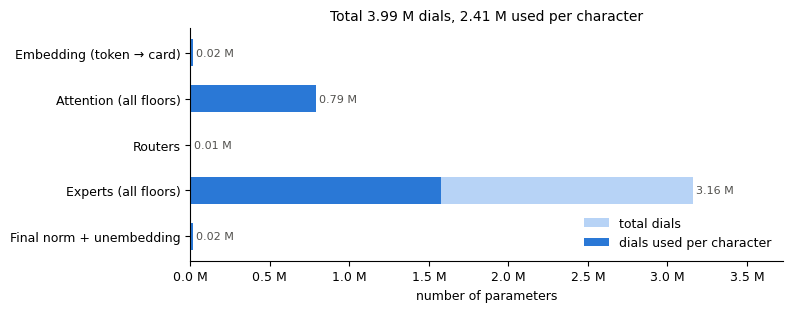

In [3]:
groups = {"Embedding (token → card)": 0, "Attention (all floors)": 0, "Routers": 0,
          "Experts (all floors)": 0, "Final norm + unembedding": 0}
for name, p in model.named_parameters():
    n = p.numel()
    if name.startswith("embedding"):            groups["Embedding (token → card)"] += n
    elif ".attn." in name:                      groups["Attention (all floors)"] += n
    elif ".mlp.router" in name or ".mlp.norm" in name: groups["Routers"] += n
    elif ".mlp.experts" in name:                groups["Experts (all floors)"] += n
    else:                                       groups["Final norm + unembedding"] += n
active = dict(groups)
active["Experts (all floors)"] = groups["Experts (all floors)"] * cfg.experts_per_token // cfg.num_experts

fig, ax = plt.subplots(figsize=(8, 3.2))
names = list(groups)
ypos = np.arange(len(names))
ax.barh(ypos, [groups[n] for n in names], color="#b7d3f6", height=0.6, label="total dials")
ax.barh(ypos, [active[n] for n in names], color=PAL[0], height=0.6, label="dials used per character")
for i, n in enumerate(names):
    ax.text(groups[n] + 20000, i, f"{groups[n]/1e6:.2f} M", va="center", fontsize=8, color="#52514e")
ax.set_yticks(ypos); ax.set_yticklabels(names); ax.invert_yaxis()
ax.set_xlabel("number of parameters"); ax.set_xlim(0, max(groups.values()) * 1.18)
ax.xaxis.set_major_formatter(lambda v, _: f"{v/1e6:.1f} M")
ax.legend(frameon=False, loc="lower right")
total, act = model.count_parameters()
ax.set_title(f"Total {total/1e6:.2f} M dials, {act/1e6:.2f} M used per character")
plt.tight_layout(); plt.show()

### 1b. The path a sentence takes

We attach a "shape recorder" to every stage and push the prompt through. The numbers are the size of the data at each stage: `(characters, width)`. Notice that the width never changes after the embedding: every floor *edits* the same 256-number card for each character rather than producing something new. Only the very last stage turns the card into 65 scores, one per possible next character.

In [4]:
shapes = []
def hook(label):
    return lambda module, inp, out: shapes.append((label, tuple(out.shape[1:])))
handles = [model.embedding.register_forward_hook(hook("Embedding lookup"))]
for i, b in enumerate(model.blocks):
    kind = "window" if b.attn.sliding_window else "dense"
    handles.append(b.attn.register_forward_hook(hook(f"Floor {i}: attention ({kind}) + add")))
    handles.append(b.mlp.register_forward_hook(hook(f"Floor {i}: experts (top-{cfg.experts_per_token} of {cfg.num_experts}) + add")))
handles.append(model.norm.register_forward_hook(hook("Final RMSNorm")))
handles.append(model.unembedding.register_forward_hook(hook("Unembedding → scores")))
with torch.no_grad():
    model(torch.tensor([tok.encode(PROMPT)], device=device))
for h in handles: h.remove()

print(f"{'stage':<48}{'shape (characters, width)':>26}")
print("-" * 74)
print(f"{'Text: ' + repr(PROMPT[:30] + '...'):<48}{'(' + str(len(PROMPT)) + ',)':>26}")
for label, shape in shapes:
    print(f"{label:<48}{str(shape):>26}")
print(f"{'Softmax → probability of each next character':<48}{str(shapes[-1][1]):>26}")

stage                                            shape (characters, width)
--------------------------------------------------------------------------
Text: 'Shall I compare thee to a summ...'                            (53,)
Embedding lookup                                                 (53, 256)
Floor 0: attention (window) + add                                (53, 256)
Floor 0: experts (top-2 of 4) + add                              (53, 256)
Floor 1: attention (dense) + add                                 (53, 256)
Floor 1: experts (top-2 of 4) + add                              (53, 256)
Floor 2: attention (window) + add                                (53, 256)
Floor 2: experts (top-2 of 4) + add                              (53, 256)
Floor 3: attention (dense) + add                                 (53, 256)
Floor 3: experts (top-2 of 4) + add                              (53, 256)
Final RMSNorm                                                    (53, 256)
Unembedding → scores     

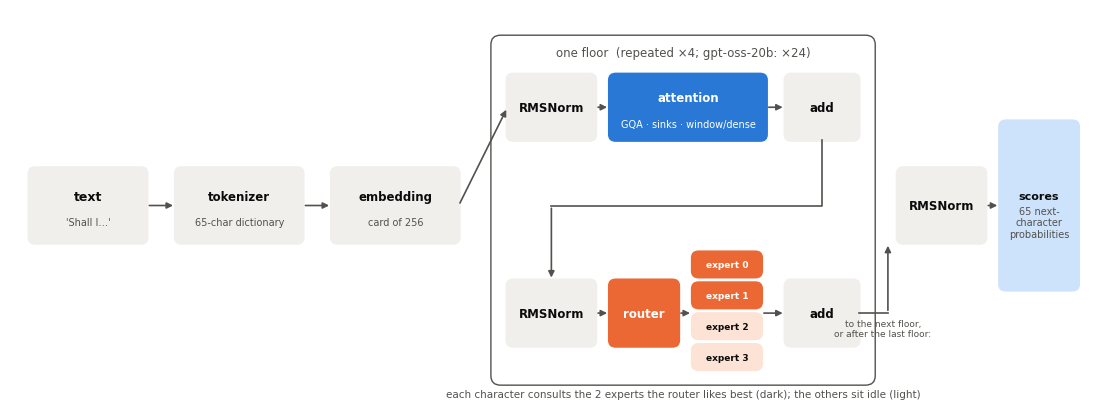

In [5]:
# The same path as a picture. Blue = attention (looking around), orange = experts (thinking), grey = bookkeeping.
fig, ax = plt.subplots(figsize=(11, 4.2)); ax.axis("off"); ax.set_xlim(0, 11); ax.set_ylim(0, 4.2)
def box(x, y, w, h, label, color, sub=None, fs=8.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=color, edgecolor="none"))
    ax.text(x + w / 2, y + h / 2 + (0.1 if sub else 0), label, ha="center", va="center", fontsize=fs,
            color="white" if color not in ("#f0efec", "#cde2fb", "#fde3d6") else "#0b0b0b", weight="bold")
    if sub: ax.text(x + w / 2, y + h / 2 - 0.18, sub, ha="center", va="center", fontsize=7,
                    color="white" if color not in ("#f0efec", "#cde2fb", "#fde3d6") else "#52514e")
def arrow(x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="-|>", color="#52514e", lw=1.2))

box(0.2, 1.7, 1.2, 0.8, "text", "#f0efec", "'Shall I…'", fs=9)
box(1.7, 1.7, 1.3, 0.8, "tokenizer", "#f0efec", f"{len(tok)}-char dictionary")
box(3.3, 1.7, 1.3, 0.8, "embedding", "#f0efec", f"card of {cfg.hidden_size}")
# one floor, expanded
ax.add_patch(FancyBboxPatch((4.95, 0.2), 3.9, 3.7, boxstyle="round,pad=0.02,rounding_size=0.1",
                            facecolor="none", edgecolor="#52514e", lw=1))
ax.text(6.9, 3.7, f"one floor  (repeated ×{cfg.num_hidden_layers}; gpt-oss-20b: ×24)", ha="center", fontsize=8.5, color="#52514e")
# upper row: look around
box(5.1, 2.8, 0.9, 0.7, "RMSNorm", "#f0efec")
box(6.15, 2.8, 1.6, 0.7, "attention", PAL[0], f"GQA · sinks · window/dense")
box(7.95, 2.8, 0.75, 0.7, "add", "#f0efec")
# lower row: think
box(5.1, 0.6, 0.9, 0.7, "RMSNorm", "#f0efec")
box(6.15, 0.6, 0.7, 0.7, "router", PAL[1])
for j in range(cfg.num_experts):
    box(7.0, 0.35 + (cfg.num_experts - 1 - j) * 0.33, 0.7, 0.26, f"expert {j}",
        PAL[1] if j < cfg.experts_per_token else "#fde3d6", fs=6.5)
box(7.95, 0.6, 0.75, 0.7, "add", "#f0efec")
for (x0, y0, x1, y1) in [(1.4, 2.1, 1.7, 2.1), (3.0, 2.1, 3.3, 2.1), (4.6, 2.1, 5.1, 3.15), (6.0, 3.15, 6.15, 3.15),
                         (7.75, 3.15, 7.95, 3.15), (6.0, 0.95, 6.15, 0.95), (6.85, 0.95, 7.0, 0.95), (7.7, 0.95, 7.95, 0.95)]:
    arrow(x0, y0, x1, y1)
# the hand-off between the rows runs in the gap between them, touching no box
ax.plot([8.325, 8.325, 5.55], [2.8, 2.1, 2.1], color="#52514e", lw=1.2)
arrow(5.55, 2.1, 5.55, 1.3)
box(9.1, 1.7, 0.9, 0.8, "RMSNorm", "#f0efec")
box(10.15, 1.2, 0.8, 1.8, "scores", "#cde2fb", f"{len(tok)} next-\ncharacter\nprobabilities", fs=8)
ax.plot([8.7, 9.0], [0.95, 0.95], color="#52514e", lw=1.2); arrow(9.0, 0.95, 9.0, 1.7)
ax.text(8.95, 0.7, "to the next floor,\nor after the last floor:", ha="center", fontsize=6.5, color="#52514e")
arrow(10.0, 2.1, 10.15, 2.1)
ax.text(6.9, 0.05, "each character consults the 2 experts the router likes best (dark); the others sit idle (light)",
        ha="center", fontsize=7.5, color="#52514e")
plt.tight_layout(); plt.show()

## 2. Embeddings: did the model learn what kind of thing each character is?

Nobody told the model that `a` and `e` are vowels or that `,` and `.` are punctuation. It only saw which character tends to follow which. The model holds two 256-number cards per character:

- the **input card** (embedding), used when the character is *read*;
- the **output card** (unembedding), used when the character is *predicted*: the final score for a character is how well the finished card matches its output card.

We squeeze both sets of cards down to 2 numbers (with PCA, a standard way to flatten high-dimensional data) and plot them, coloured by a class we assign *after* training.

**What to look for:** the input cards are scattered at random. A tiny model with only 65 characters does not need them to mean anything: they work as ID badges, and attention does the real work. The output cards are different: characters that are predicted in the same situations (vowels inside words, punctuation at word ends) end up near each other. The model discovered the classes on the output side, on its own.

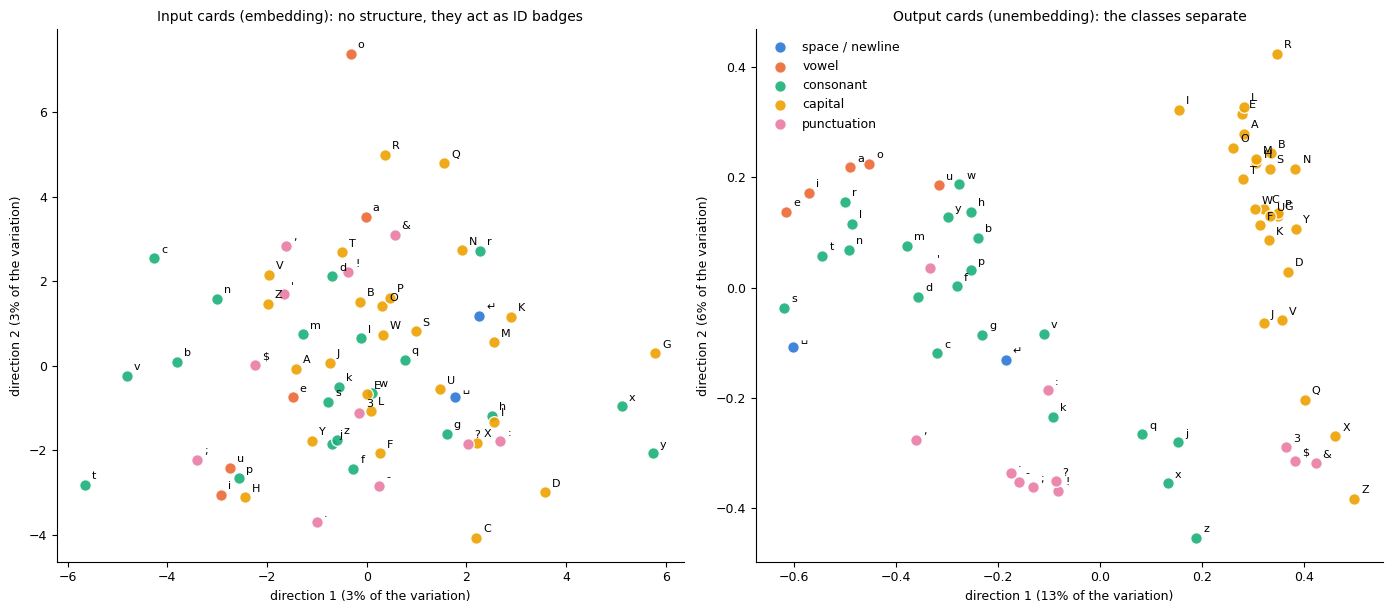

In [6]:
def flatten_2d(M):
    M = M - M.mean(0, keepdim=True)
    U, S, V = torch.pca_lowrank(M, q=2, center=False)
    return (M @ V[:, :2]).numpy(), (S[:2] ** 2 / (M ** 2).sum()).numpy()

E_in = model.embedding.weight.detach().cpu().float()
E_out = model.unembedding.weight.detach().cpu().float()
fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
for ax, (title, M) in zip(axes, [("Input cards (embedding): no structure, they act as ID badges", E_in),
                                  ("Output cards (unembedding): the classes separate", E_out)]):
    xy, explained = flatten_2d(M)
    for cls in CLASSES:
        idx = [i for i, c in enumerate(tok.chars) if char_class(c) == cls]
        ax.scatter(xy[idx, 0], xy[idx, 1], s=70, color=CLASS_COLOR[cls], label=cls, alpha=0.9, edgecolor="white", linewidth=1)
        for i in idx:
            ax.annotate(show(tok.chars[i]), (xy[i, 0], xy[i, 1]), xytext=(5, 4), textcoords="offset points", fontsize=8)
    ax.set_xlabel(f"direction 1 ({explained[0]:.0%} of the variation)")
    ax.set_ylabel(f"direction 2 ({explained[1]:.0%} of the variation)")
    ax.set_title(title)
axes[1].legend(frameon=False, loc="best")
plt.tight_layout(); plt.show()

Another way to ask the same question: for a few characters, which other characters have the most similar **output** card? (Cosine similarity: 1 = identical direction, 0 = unrelated.) Vowels find vowels, and the space finds the other characters that end words.

In [7]:
En = F.normalize(E_out - E_out.mean(0, keepdim=True), dim=-1)
sim = En @ En.T
for c in ["e", "a", "t", " ", ",", "T", "Q"]:
    i = tok.stoi[c]
    order = sim[i].argsort(descending=True)[1:6]
    neighbours = ", ".join(f"{show(tok.chars[j])} ({sim[i, j]:.2f})" for j in order)
    print(f"{show(c):>2}  ({char_class(c):<15}) closest: {neighbours}")

 e  (vowel          ) closest: i (0.44), a (0.42), o (0.38), s (0.24), t (0.24)
 a  (vowel          ) closest: e (0.42), o (0.40), i (0.37), u (0.25), r (0.24)
 t  (consonant      ) closest: s (0.32), n (0.29), c (0.27), l (0.26), d (0.25)
 ␣  (space / newline) closest: , (0.52), . (0.32), s (0.32), ↵ (0.31), ; (0.30)
 ,  (punctuation    ) closest: ␣ (0.52), ; (0.51), . (0.50), ! (0.45), ? (0.38)
 T  (capital        ) closest: D (0.26), F (0.24), B (0.23), A (0.22), W (0.20)
 Q  (capital        ) closest: J (0.47), & (0.41), $ (0.36), 3 (0.33), K (0.31)


## 3. RoPE: the position clock hands

RoPE rotates each pair of numbers in a card by an angle that grows with position. Different pairs turn at different speeds. Here are the cosine of that angle for a fast, a medium and a slow pair across the first 64 positions. A fast hand distinguishes neighbours; a slow hand distinguishes "early in the text" from "late in the text". Together, every position gets a unique fingerprint, and the *difference* between two fingerprints depends only on the distance between them.

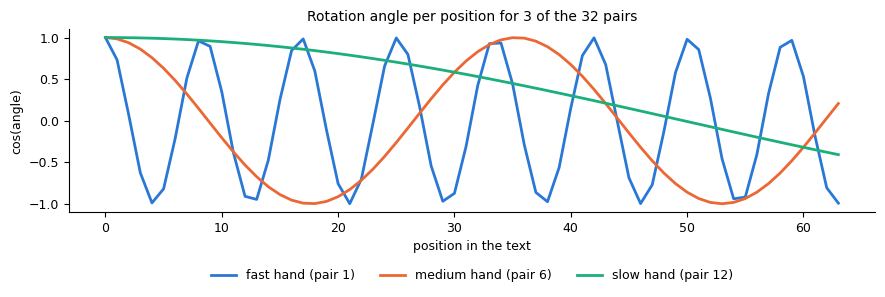

In [8]:
rope = model.blocks[0].attn.rope
cos, sin = rope.cos_sin(64, "cpu")
pairs = {"fast hand (pair 1)": 1, "medium hand (pair 6)": 6, "slow hand (pair 12)": 12}
fig, ax = plt.subplots(figsize=(9, 3.2))
for (label, p), color in zip(pairs.items(), PAL):
    ax.plot(cos[:, p].numpy(), color=color, lw=2, label=label)
ax.set_xlabel("position in the text"); ax.set_ylabel("cos(angle)")
ax.set_title(f"Rotation angle per position for 3 of the {cfg.head_dim // 2} pairs")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.tight_layout(); plt.show()

## 4. Attention: where does each head look?

The prompt is 53 characters long, longer than the 32-character sliding window, so on floors 0 and 2 the later characters cannot see the start of the prompt (the blank lower-left corner). Floors 1 and 3 see everything.

Each cell is "how much the character on the row paid attention to the character in the column". Darker is more.

**What to look for:**
- A strong diagonal means "look at yourself or the last character" (useful for spelling).
- Vertical stripes mean "everyone looks at this one character" (often a space or the start of a word).
- Heads on the same floor look at different things: that is the point of having several.

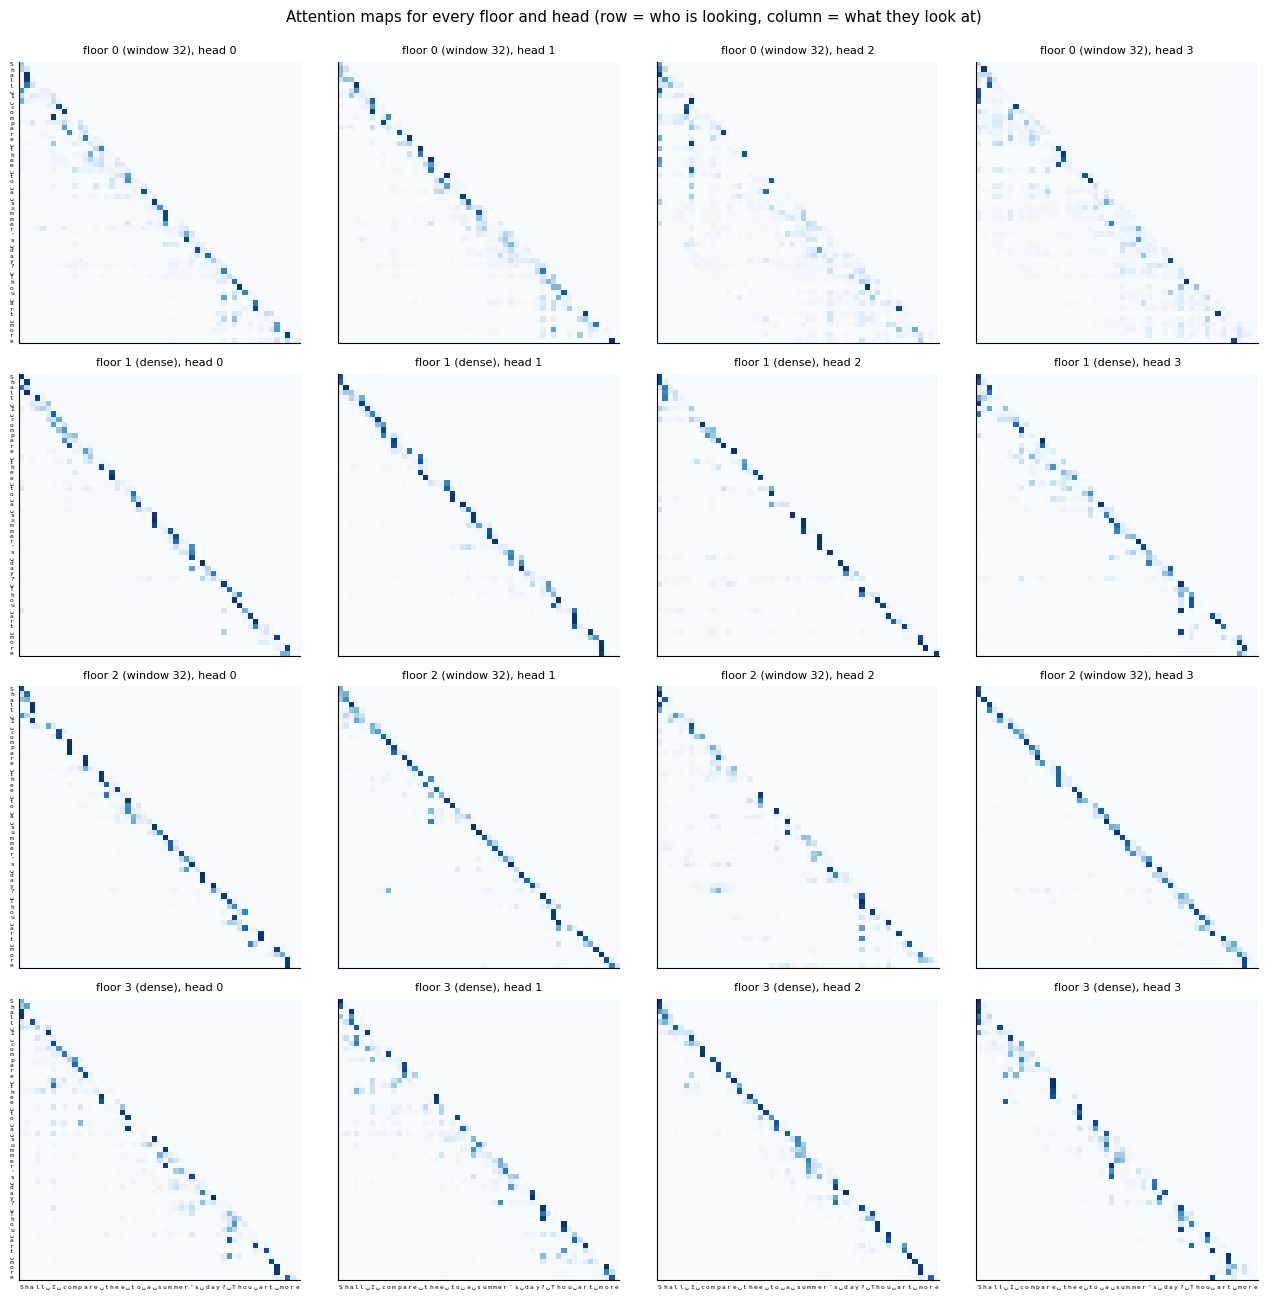

In [9]:
T = len(PROMPT)
fig, axes = plt.subplots(cfg.num_hidden_layers, cfg.num_attention_heads, figsize=(13, 13))
for l, block in enumerate(model.blocks):
    W = block.attn.last_weights[0].cpu()          # (heads, T, T+1)
    kind = f"window {cfg.sliding_window}" if block.attn.sliding_window else "dense"
    for h in range(cfg.num_attention_heads):
        ax = axes[l, h]
        ax.imshow(W[h, :, :T], cmap=SEQ, vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(f"floor {l} ({kind}), head {h}", fontsize=8)
        ax.set_xticks(range(T)); ax.set_yticks(range(T))
        ax.set_xticklabels([show(c) for c in PROMPT] if l == cfg.num_hidden_layers - 1 else [], fontsize=4.5, family="monospace")
        ax.set_yticklabels([show(c) for c in PROMPT] if h == 0 else [], fontsize=4.5, family="monospace")
        ax.tick_params(length=0)
plt.suptitle("Attention maps for every floor and head (row = who is looking, column = what they look at)", y=0.995)
plt.tight_layout(); plt.show()

### 4b. How much attention goes to the "nobody" sink?

GPT-OSS gives every head a learnable sink: an extra slot the head can attend to instead of any real character. Attention paid to the sink is thrown away. We measure, over 32 unseen snippets of 128 characters, what fraction of each head's attention went to its sink.

**What to look for:** in this small model the sinks are used lightly, a few percent of each head's attention, and two heads on the last floor have switched them off almost entirely. That is the expected picture for a model whose context is short: with 65 characters and 128-character snippets there is almost always something relevant to look at. The sink matters most in the real model, where a head scanning 128,000 tokens often finds nothing worth attending to and needs somewhere harmless to put its attention.

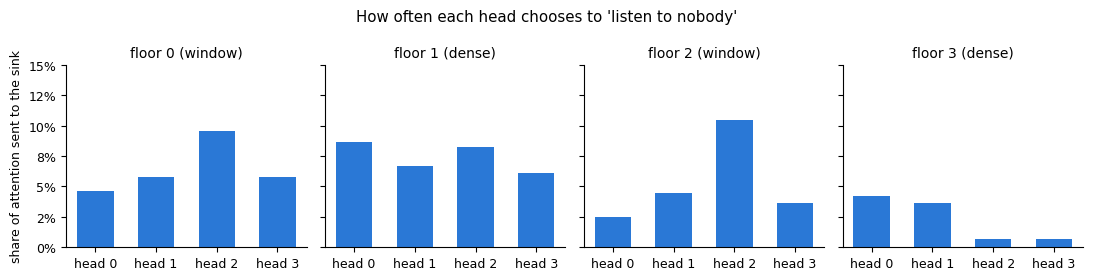

In [10]:
val_ids = torch.tensor(tok.encode(val_text), dtype=torch.long)
starts = torch.randint(0, len(val_ids) - cfg.block_size - 1, (32,))
xb = torch.stack([val_ids[s: s + cfg.block_size] for s in starts]).to(device)
yb = torch.stack([val_ids[s + 1: s + cfg.block_size + 1] for s in starts]).to(device)
with torch.no_grad():
    model.set_record(True); model(xb); model.set_record(False)

sink_share = np.array([[block.attn.last_weights[:, h, :, -1].mean().item() for h in range(cfg.num_attention_heads)]
                       for block in model.blocks])
fig, axes = plt.subplots(1, cfg.num_hidden_layers, figsize=(11, 2.8), sharey=True)
for l, ax in enumerate(axes):
    ax.bar(range(cfg.num_attention_heads), sink_share[l], color=PAL[0], width=0.6)
    ax.set_title(f"floor {l} ({'window' if model.blocks[l].attn.sliding_window else 'dense'})")
    ax.set_xticks(range(cfg.num_attention_heads)); ax.set_xticklabels([f"head {h}" for h in range(cfg.num_attention_heads)])
    ax.set_ylim(0, max(0.15, sink_share.max() * 1.25))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[0].set_ylabel("share of attention sent to the sink")
plt.suptitle("How often each head chooses to 'listen to nobody'")
plt.tight_layout(); plt.show()

### 4c. What is the model staring at right before it guesses?

Take the last character of the prompt (`e` in *"more"*). Which earlier characters did it attend to on each floor (averaged over the floor's heads)? Darker = more attention. This is the model's "field of view" at the moment it decides what to write next.

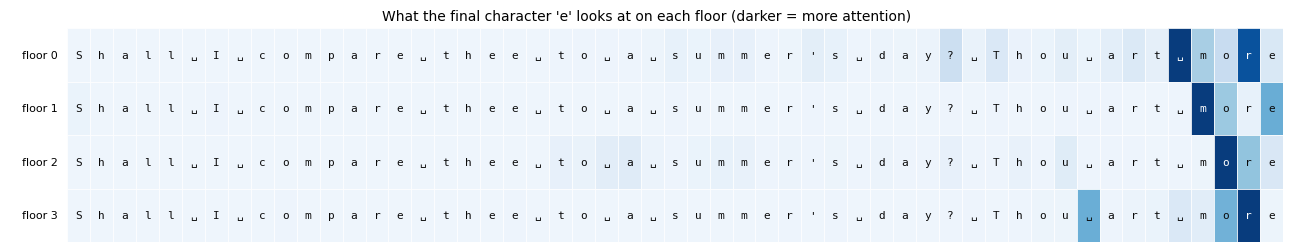

Its guess for the next character: '␣' 77%, ',' 10%, '↵' 3%


In [11]:
fig, ax = plt.subplots(figsize=(13, 2.6))
for l, block in enumerate(model.blocks):
    W = block.attn.last_weights                   # from the batch run; re-run the prompt for its weights
_, _, _ = run(PROMPT)
for l, block in enumerate(model.blocks):
    gaze = block.attn.last_weights[0, :, -1, :T].mean(0).cpu().numpy()   # last character, avg over heads
    paint_text(ax, PROMPT, gaze, y=cfg.num_hidden_layers - 1 - l, vmax=gaze.max())
    ax.text(-0.4, cfg.num_hidden_layers - 1 - l + 0.5, f"floor {l}", ha="right", va="center", fontsize=8)
ax.set_xlim(-2.5, T); ax.set_ylim(0, cfg.num_hidden_layers); ax.axis("off")
ax.set_title(f"What the final character '{PROMPT[-1]}' looks at on each floor (darker = more attention)")
plt.tight_layout(); plt.show()
with torch.no_grad():
    probs = torch.softmax(logits[-1], dim=-1)
top = probs.topk(3)
print("Its guess for the next character:", ", ".join(f"'{show(tok.chars[i])}' {p:.0%}" for p, i in zip(top.values.tolist(), top.indices.tolist())))

## 5. Experts: which specialist handles which character?

On every floor a router looks at each character's card and sends it to its 2 favourite experts out of 4. Here, for the prompt, each cell shows the router's **first choice** (colour) on each floor, and the router's confidence in it (darker = more confident).

**What to look for:** the same character does not always go to the same expert; the router looks at the card *after* attention, so context matters. But patterns do appear, for instance spaces often share an expert.

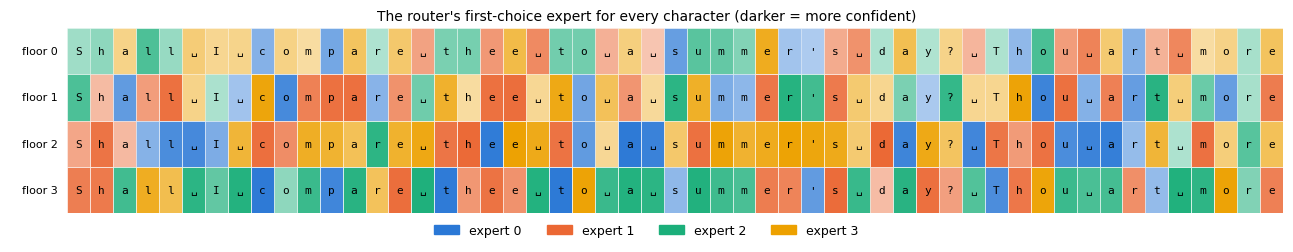

In [12]:
_, _, _ = run(PROMPT)
expert_cmap = ListedColormap(PAL[: cfg.num_experts])
fig, ax = plt.subplots(figsize=(13, 2.6))
for l, block in enumerate(model.blocks):
    top1 = block.mlp.last_top_idx[:, 0].cpu().numpy()
    conf = block.mlp.last_top_w[:, 0].cpu().numpy()      # blend weight of the first choice (0.5 .. 1)
    y = cfg.num_hidden_layers - 1 - l
    for i, c in enumerate(PROMPT):
        alpha = 0.35 + 0.65 * (conf[i] - 0.5) / 0.5
        ax.add_patch(Rectangle((i, y), 1, 1, facecolor=PAL[top1[i]], alpha=alpha, edgecolor="white", linewidth=0.5))
        ax.text(i + 0.5, y + 0.5, show(c), ha="center", va="center", fontsize=8, family="monospace")
    ax.text(-0.4, y + 0.5, f"floor {l}", ha="right", va="center", fontsize=8)
ax.set_xlim(-2.5, T); ax.set_ylim(0, cfg.num_hidden_layers); ax.axis("off")
ax.legend(handles=[Patch(color=PAL[e], label=f"expert {e}") for e in range(cfg.num_experts)],
          frameon=False, ncol=cfg.num_experts, loc="upper center", bbox_to_anchor=(0.5, 0))
ax.set_title("The router's first-choice expert for every character (darker = more confident)")
plt.tight_layout(); plt.show()

### 5b. Did the experts specialise?

Over the 32 unseen snippets (4,096 characters), we count what kinds of characters each expert received on each floor. If the experts were interchangeable, every bar would have the same mix.

**What to look for:** bars with a different mix from their neighbours. An expert that receives mostly spaces and punctuation has become a "word boundary" specialist; one heavy in vowels is a "middle of the word" specialist.

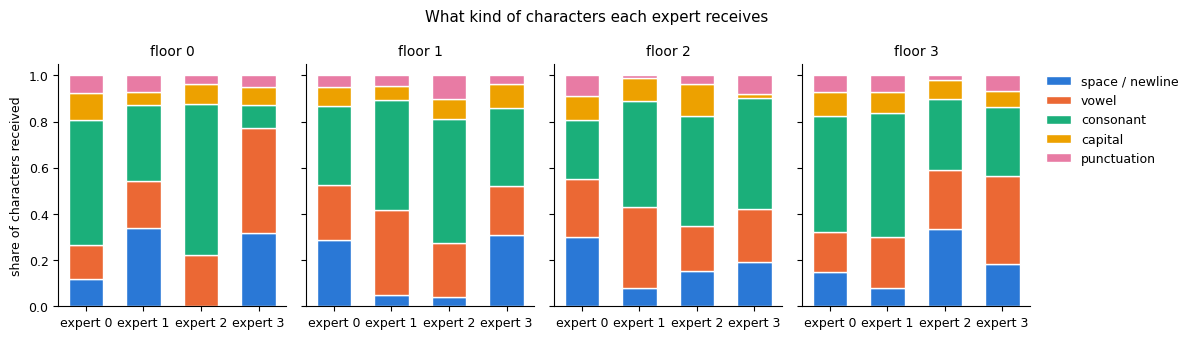

In [13]:
with torch.no_grad():
    model.set_record(True); model(xb); model.set_record(False)
flat_chars = [tok.chars[i] for i in xb.reshape(-1).tolist()]
cls_idx = np.array([CLASSES.index(char_class(c)) for c in flat_chars])

fig, axes = plt.subplots(1, cfg.num_hidden_layers, figsize=(12, 3.4), sharey=True)
for l, (ax, block) in enumerate(zip(axes, model.blocks)):
    top_idx = block.mlp.last_top_idx.cpu().numpy()                 # (N, k)
    mix = np.zeros((cfg.num_experts, len(CLASSES)))
    for slot in range(cfg.experts_per_token):
        np.add.at(mix, (top_idx[:, slot], cls_idx), 1)
    mix = mix / mix.sum(1, keepdims=True)
    bottom = np.zeros(cfg.num_experts)
    for ci, cls in enumerate(CLASSES):
        ax.bar(range(cfg.num_experts), mix[:, ci], bottom=bottom, color=CLASS_COLOR[cls], width=0.6,
               label=cls, edgecolor="white", linewidth=1)
        bottom += mix[:, ci]
    ax.set_title(f"floor {l}"); ax.set_xticks(range(cfg.num_experts)); ax.set_xticklabels([f"expert {e}" for e in range(cfg.num_experts)])
axes[0].set_ylabel("share of characters received")
axes[-1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.suptitle("What kind of characters each expert receives")
plt.tight_layout(); plt.show()

### 5c. The SwiGLU gate

Inside each expert, half of the numbers act as a **gate**. GPT-OSS's gate is `x · sigmoid(1.702 x)`, clamped so it never exceeds 7. Compared with the classic ReLU (which is simply "off below zero, pass-through above"), it is smooth, lets a little negative signal through, and stops growing at the clamp.

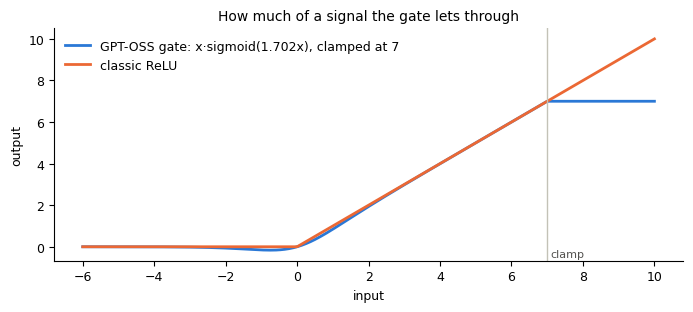

In [14]:
x = torch.linspace(-6, 10, 400)
gate = mg.swiglu(torch.stack([x, torch.zeros_like(x)], dim=-1).reshape(-1))   # linear half = 0 → output = gate·1
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(x, gate, color=PAL[0], lw=2, label="GPT-OSS gate: x·sigmoid(1.702x), clamped at 7")
ax.plot(x, torch.relu(x), color=PAL[1], lw=2, label="classic ReLU")
ax.axvline(7, color="#c3c2b7", lw=1); ax.text(7.1, -0.5, "clamp", color="#52514e", fontsize=8)
ax.set_xlabel("input"); ax.set_ylabel("output"); ax.set_title("How much of a signal the gate lets through")
ax.legend(frameon=False, loc="upper left"); plt.tight_layout(); plt.show()

## 6. Depth: how the guess sharpens floor by floor

Here is a trick called the **logit lens**. The final stage of the model (RMSNorm + unembedding) turns a card into next-character scores. Nothing stops us from applying that final stage to the card *as it is after each floor*. That shows what the model would guess if it stopped early.

Below, for a line of text the model never saw, each cell is the probability the model gives to the **correct** next character after floor 0, 1, 2, 3. The top row (embedding only) is the guess with no floors at all.

**What to look for:** columns get darker from top to bottom. The floors are doing real work. Some characters are easy from the start (the `u` after `q`), others need all four floors.

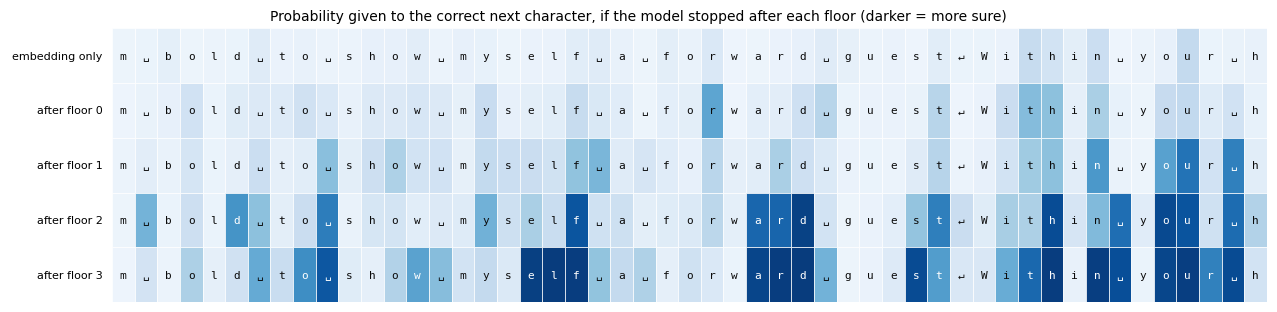

Average probability on the correct character: embedding only: 0.04, after floor 0: 0.11, after floor 1: 0.18, after floor 2: 0.33, after floor 3: 0.44


In [15]:
line_start = val_text.find("\n", 500) + 1
LINE = val_text[line_start: line_start + 52]
ids_l, logits_l, hidden_l = run(LINE)
targets = ids_l[1:]
lens = []
with torch.no_grad():
    for hcard in hidden_l:
        p = torch.softmax(model.unembedding(model.norm(hcard[0])), dim=-1)     # (T, vocab)
        lens.append(p[torch.arange(len(LINE) - 1), targets].cpu().numpy())
lens = np.array(lens)                                                        # (floors+1, T-1)

fig, ax = plt.subplots(figsize=(13, 3.2))
rows = ["embedding only"] + [f"after floor {l}" for l in range(cfg.num_hidden_layers)]
for r, (label, vals) in enumerate(zip(rows, lens)):
    paint_text(ax, LINE[1:], vals, y=len(rows) - 1 - r, vmax=1.0)
    ax.text(-0.4, len(rows) - 1 - r + 0.5, label, ha="right", va="center", fontsize=8)
ax.set_xlim(-4.5, len(LINE) - 1); ax.set_ylim(0, len(rows)); ax.axis("off")
ax.set_title("Probability given to the correct next character, if the model stopped after each floor (darker = more sure)")
plt.tight_layout(); plt.show()
print("Average probability on the correct character:", ", ".join(f"{r}: {v.mean():.2f}" for r, v in zip(rows, lens)))

The same story as one line per floor: the model's total "surprise" (loss) on the unseen snippets if it stopped after each floor. Lower is better; the dashed grey line is random guessing.

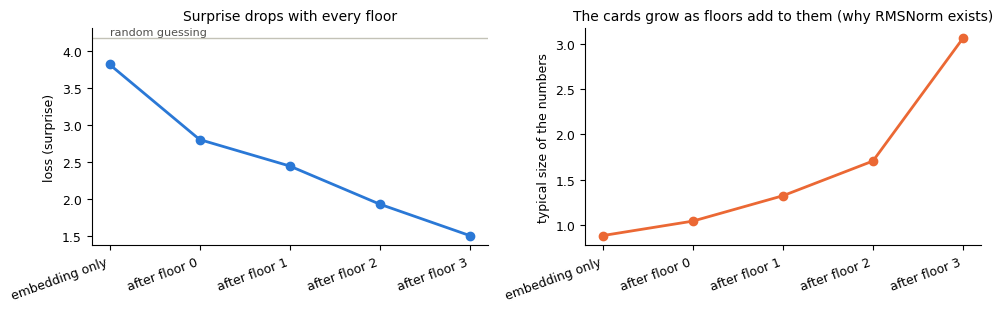

In [16]:
with torch.no_grad():
    _, _, hidden_b = model(xb, return_hidden=True)
    stage_loss = [F.cross_entropy(model.unembedding(model.norm(h)).reshape(-1, len(tok)), yb.reshape(-1)).item() for h in hidden_b]
    stream_rms = [h.float().pow(2).mean().sqrt().item() for h in hidden_b]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
xs = range(len(rows))
axes[0].plot(xs, stage_loss, marker="o", color=PAL[0], lw=2)
axes[0].axhline(math.log(len(tok)), color="#c3c2b7", lw=1); axes[0].text(0, math.log(len(tok)) + 0.05, "random guessing", fontsize=8, color="#52514e")
axes[0].set_xticks(xs); axes[0].set_xticklabels(rows, rotation=20, ha="right"); axes[0].set_ylabel("loss (surprise)")
axes[0].set_title("Surprise drops with every floor")
axes[1].plot(xs, stream_rms, marker="o", color=PAL[1], lw=2)
axes[1].set_xticks(xs); axes[1].set_xticklabels(rows, rotation=20, ha="right"); axes[1].set_ylabel("typical size of the numbers")
axes[1].set_title("The cards grow as floors add to them (why RMSNorm exists)")
plt.tight_layout(); plt.show()

## 7. The guess

### 7a. Top candidates and the temperature knob

For the prompt, here are the model's ten most likely next characters. **Temperature** rescales the scores before they become probabilities: a low temperature makes the model cautious (it almost always picks the favourite), a high one makes it adventurous (long tail of options). This is the knob behind "creative" versus "precise" settings in chat apps.

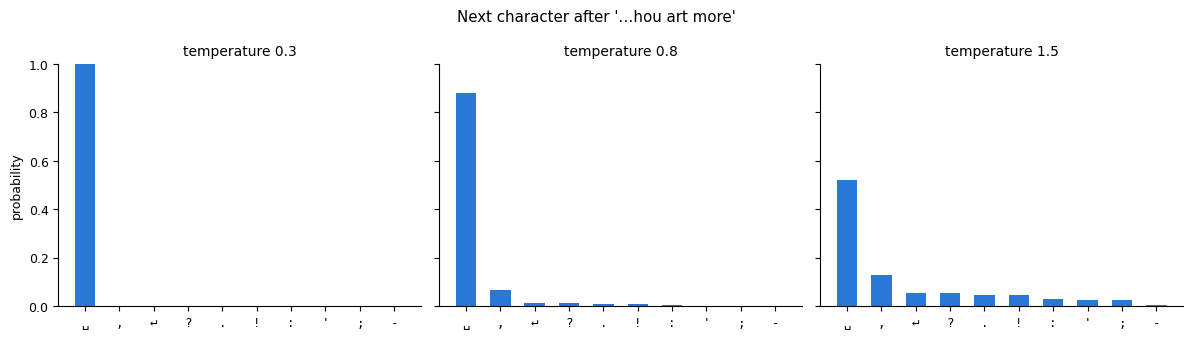

In [17]:
last = logits[-1].cpu()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, temp in zip(axes, [0.3, 0.8, 1.5]):
    p = torch.softmax(last / temp, dim=-1)
    top = p.topk(10)
    ax.bar(range(10), top.values.numpy(), color=PAL[0], width=0.6)
    ax.set_xticks(range(10)); ax.set_xticklabels([show(tok.chars[i]) for i in top.indices.tolist()], family="monospace")
    ax.set_title(f"temperature {temp}"); ax.set_ylim(0, 1)
axes[0].set_ylabel("probability")
plt.suptitle(f"Next character after '…{PROMPT[-12:]}'")
plt.tight_layout(); plt.show()

### 7b. Watching it write, one character at a time

We let the model write 24 characters after `ROMEO:` and record its top-5 candidates at every step. Each row is one step; the shade is the probability; the character it actually picked is marked with a dot. Most of the time the favourite wins, but sampling sometimes picks a runner-up, and that is what makes every run different.

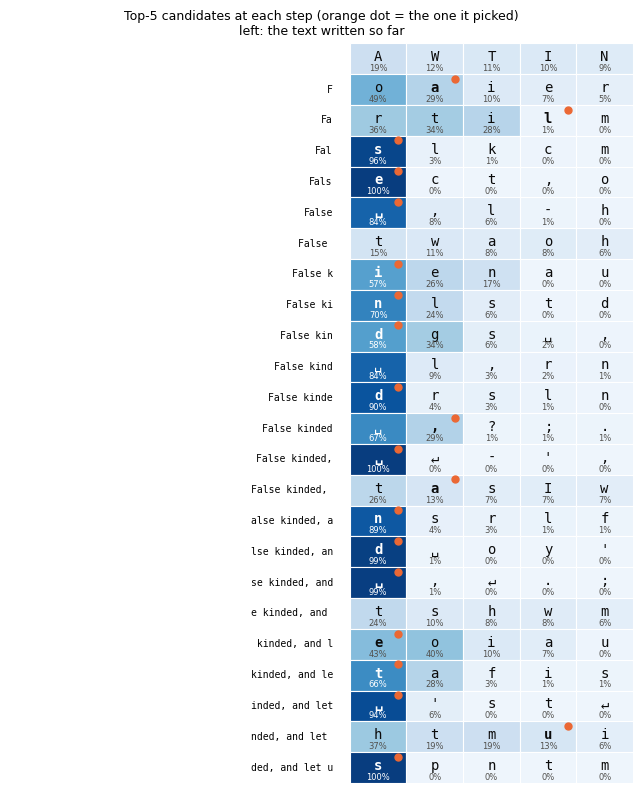

It wrote: 'ROMEO:\nFalse kinded, and let us'


In [18]:
STEPS, TOPN = 24, 5
trace, out_ids = [], torch.tensor([tok.encode("ROMEO:\n")], device=device)
torch.manual_seed(3)
with torch.no_grad():
    for _ in range(STEPS):
        lg, _ = model(out_ids[:, -cfg.block_size:])
        p = torch.softmax(lg[0, -1] / 0.8, dim=-1)
        top = p.topk(TOPN)
        nxt = torch.multinomial(p, 1)
        trace.append((top.indices.tolist(), top.values.tolist(), nxt.item()))
        out_ids = torch.cat([out_ids, nxt.view(1, 1)], dim=1)

fig, ax = plt.subplots(figsize=(6.5, 8))
cm = plt.get_cmap(SEQ)
for r, (cands, probs, chosen) in enumerate(trace):
    y = STEPS - 1 - r
    for c, (ci, pv) in enumerate(zip(cands, probs)):
        ax.add_patch(Rectangle((c, y), 1, 1, facecolor=cm(0.05 + 0.9 * pv), edgecolor="white", linewidth=0.8))
        ax.text(c + 0.5, y + 0.55, show(tok.chars[ci]), ha="center", va="center", fontsize=10, family="monospace",
                color="white" if pv > 0.55 else "#0b0b0b", weight="bold" if ci == chosen else "normal")
        ax.text(c + 0.5, y + 0.18, f"{pv:.0%}", ha="center", va="center", fontsize=6, color="white" if pv > 0.55 else "#52514e")
        if ci == chosen:
            ax.plot(c + 0.85, y + 0.85, "o", color=PAL[1], ms=5)
    ax.text(-0.3, y + 0.5, repr(tok.decode(out_ids[0, 7: 7 + r].tolist()))[1:-1][-14:], ha="right", va="center", fontsize=7, family="monospace")
ax.set_xlim(-6, TOPN); ax.set_ylim(0, STEPS); ax.axis("off")
ax.set_title("Top-5 candidates at each step (orange dot = the one it picked)\nleft: the text written so far", fontsize=9)
plt.tight_layout(); plt.show()
print("It wrote:", repr(tok.decode(out_ids[0].tolist())))

### 7c. Which characters surprise the model?

For a line of unseen text, the bar under each character is how surprised the model was when that character arrived (its loss). The first letter of a word is hard: many words could follow. The letters inside a word are easy: after `th` an `e` is no surprise. Line breaks after a colon are easy too, because the play script always does that.

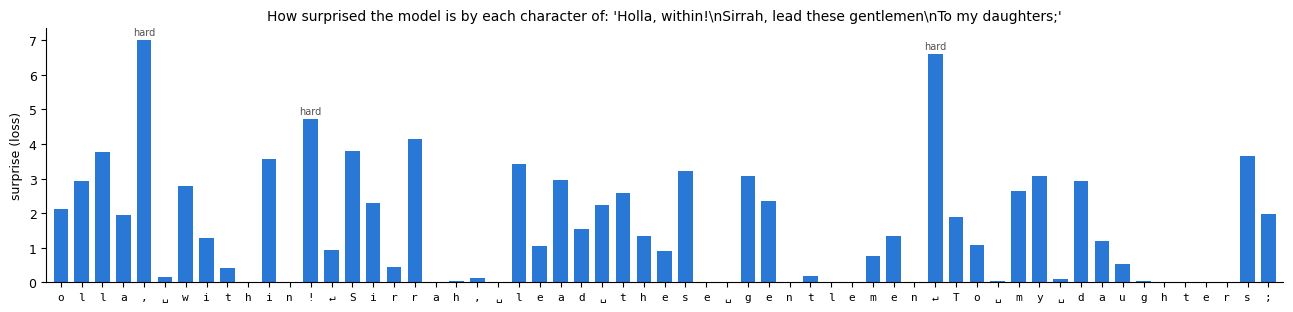

Average surprise on this line: 1.61  (random guessing would be 4.17)


In [19]:
line_start = val_text.find("\n", 3000) + 1
LINE2 = val_text[line_start: line_start + 60]
ids2, logits2, _ = run(LINE2)
with torch.no_grad():
    surprise = F.cross_entropy(logits2[:-1], ids2[1:], reduction="none").cpu().numpy()
chars2 = LINE2[1:]

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.bar(range(len(chars2)), surprise, color=PAL[0], width=0.7)
ax.set_xticks(range(len(chars2))); ax.set_xticklabels([show(c) for c in chars2], family="monospace", fontsize=8)
ax.set_ylabel("surprise (loss)"); ax.set_xlim(-0.7, len(chars2) - 0.3)
for i in surprise.argsort()[-3:]:
    ax.annotate("hard", (i, surprise[i]), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=7, color="#52514e")
ax.set_title(f"How surprised the model is by each character of: {LINE2.strip()!r}")
plt.tight_layout(); plt.show()
print(f"Average surprise on this line: {surprise.mean():.2f}  (random guessing would be {math.log(len(tok)):.2f})")

## What you have seen

- **Anatomy:** most dials live in the experts, and only half of those are used for any one character. The card width never changes; floors edit, they do not replace.
- **Embeddings:** the input cards are plain ID badges, but the output cards discovered the character classes on their own.
- **Attention:** heads specialise (diagonal "spelling" heads, vertical "word start" heads); sliding-window floors really do lose the far past; the sinks exist but a short-context model barely needs them.
- **Experts:** the router's choice depends on context, and the experts drift toward different kinds of characters.
- **Depth:** the guess sharpens with every floor, and the residual stream grows, which is why every stage starts with RMSNorm.
- **The guess:** temperature shapes the candidate list; sampling picks among the top few; word starts are hard and word insides are easy.

Everything here scales up unchanged to gpt-oss-20b: 24 floors instead of 4, 32 experts instead of 4, 64 heads instead of 4, and 201,088 tokens instead of 65 characters. The pictures would simply have more rows.

**Try it:** change `PROMPT` at the top and re-run. Long prompts (over 32 characters) show the sliding window; prompts ending mid-word show a confident model; prompts ending on a space show an uncertain one.